In [13]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
import numpy as np

from dataset.dataset import Dataset
from utils.config import load_config
from utils.builder import build_trainer

# FCN trained on female cohort

In [14]:
config_path = "../configs/fcn_f.yaml"

In [15]:
config = load_config(config_path)
data_path = "../"+config["data"]["data_path"]

torch.manual_seed(config["experiment"]["seed"])
np.random.seed(config["experiment"]["seed"])

dataset = Dataset(data_path, "G", config["data"]["batch_size"], use_tabular=config["data"]["use_tabular"], tabular_features=config["data"]["tabular_features"])
train_loader, val_loader, test_loader = dataset.get_loaders()

dataset_f = Dataset(data_path, "F", config["data"]["batch_size"])
_, val_loader_f, test_loader_f = dataset_f.get_loaders()

dataset_m = Dataset(data_path, "M", config["data"]["batch_size"])       
_, val_loader_m, test_loader_m = dataset_m.get_loaders()

In [16]:
trainer = build_trainer(config)
trainer.load_checkpoint()

## Testing with simillar threshold

In [17]:
best_thr = trainer.choose_threshold(val_loader)

Best threshold: 0.307
Sensitivity: 0.904
Specificity: 0.778
AUC: 0.937
Accuracy: 0.839


In [18]:
print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)


===== ALL =====
           TEST RESULTS
  Threshold         : 0.307
  AUC               : 0.9286
  Accuracy          : 0.8136
  Sensitivity       : 0.8987  (recall on MI)
  Specificity       : 0.7278  (recall on NORM)
  Precision         : 0.7691
  F1 Score          : 0.8289
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     548        205
  True MI    :      77        683
              precision    recall  f1-score   support

        NORM       0.88      0.73      0.80       753
          MI       0.77      0.90      0.83       760

    accuracy                           0.81      1513
   macro avg       0.82      0.81      0.81      1513
weighted avg       0.82      0.81      0.81      1513



In [19]:
print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)


===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.307
  AUC               : 0.9415
  Accuracy          : 0.8414
  Sensitivity       : 0.9260  (recall on MI)
  Specificity       : 0.7493  (recall on NORM)
  Precision         : 0.8009
  F1 Score          : 0.8590
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     251         84
  True MI    :      27        338
              precision    recall  f1-score   support

        NORM       0.90      0.75      0.82       335
          MI       0.80      0.93      0.86       365

    accuracy                           0.84       700
   macro avg       0.85      0.84      0.84       700
weighted avg       0.85      0.84      0.84       700



In [20]:
print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)


===== MALE =====
           TEST RESULTS
  Threshold         : 0.307
  AUC               : 0.9250
  Accuracy          : 0.8155
  Sensitivity       : 0.9010  (recall on MI)
  Specificity       : 0.7311  (recall on NORM)
  Precision         : 0.7679
  F1 Score          : 0.8292
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     299        110
  True MI    :      40        364
              precision    recall  f1-score   support

        NORM       0.88      0.73      0.80       409
          MI       0.77      0.90      0.83       404

    accuracy                           0.82       813
   macro avg       0.82      0.82      0.81       813
weighted avg       0.83      0.82      0.81       813



## Choosing best threshold separately for G, M and F

In [21]:
best_thr = trainer.choose_threshold(val_loader)

print("\n===== ALL =====")
out = trainer.test(test_loader, best_thr)

Best threshold: 0.398
Sensitivity: 0.909
Specificity: 0.828
AUC: 0.947
Accuracy: 0.866

===== ALL =====
           TEST RESULTS
  Threshold         : 0.398
  AUC               : 0.9325
  Accuracy          : 0.8519
  Sensitivity       : 0.8853  (recall on MI)
  Specificity       : 0.8191  (recall on NORM)
  Precision         : 0.8279
  F1 Score          : 0.8557
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     625        138
  True MI    :      86        664
              precision    recall  f1-score   support

        NORM       0.88      0.82      0.85       763
          MI       0.83      0.89      0.86       750

    accuracy                           0.85      1513
   macro avg       0.85      0.85      0.85      1513
weighted avg       0.85      0.85      0.85      1513



In [22]:
best_thr = trainer.choose_threshold(val_loader_f)

print("\n===== FEMALE =====")
out = trainer.test(test_loader_f, best_thr)

Best threshold: 0.205
Sensitivity: 0.942
Specificity: 0.790
AUC: 0.947
Accuracy: 0.863

===== FEMALE =====
           TEST RESULTS
  Threshold         : 0.205
  AUC               : 0.9243
  Accuracy          : 0.8100
  Sensitivity       : 0.9368  (recall on MI)
  Specificity       : 0.6594  (recall on NORM)
  Precision         : 0.7656
  F1 Score          : 0.8426
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     211        109
  True MI    :      24        356
              precision    recall  f1-score   support

        NORM       0.90      0.66      0.76       320
          MI       0.77      0.94      0.84       380

    accuracy                           0.81       700
   macro avg       0.83      0.80      0.80       700
weighted avg       0.83      0.81      0.81       700



In [23]:
best_thr = trainer.choose_threshold(val_loader_m)

print("\n===== MALE =====")
out = trainer.test(test_loader_m, best_thr)

Best threshold: 0.476
Sensitivity: 0.903
Specificity: 0.824
AUC: 0.943
Accuracy: 0.864

===== MALE =====
           TEST RESULTS
  Threshold         : 0.476
  AUC               : 0.9281
  Accuracy          : 0.8573
  Sensitivity       : 0.8863  (recall on MI)
  Specificity       : 0.8246  (recall on NORM)
  Precision         : 0.8508
  F1 Score          : 0.8682
  Confusion Matrix
               Pred NORM   Pred MI
  True NORM  :     315         67
  True MI    :      49        382
              precision    recall  f1-score   support

        NORM       0.87      0.82      0.84       382
          MI       0.85      0.89      0.87       431

    accuracy                           0.86       813
   macro avg       0.86      0.86      0.86       813
weighted avg       0.86      0.86      0.86       813



### ROC curves

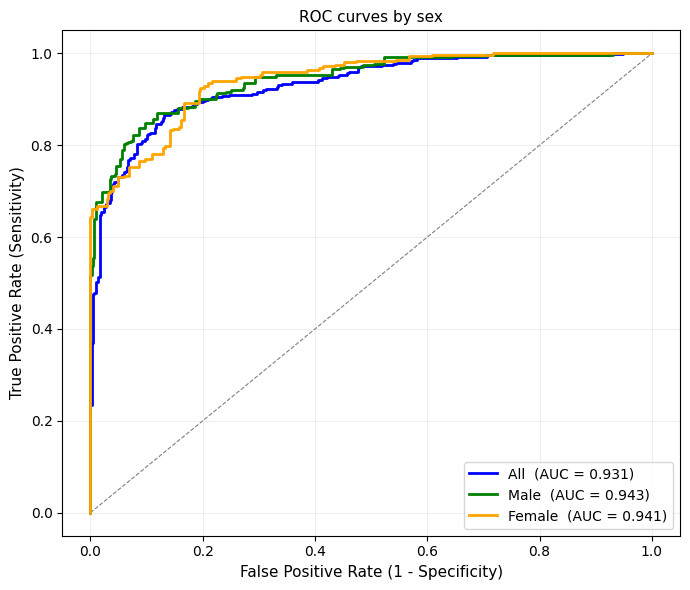

In [24]:
from utils.metrics import plot_roc_curves

plot_roc_curves(
    trainer,
    loaders_dict={
        'All':    test_loader,
        'Male':   test_loader_m,
        'Female': test_loader_f,
    }
)